In [110]:
import torch
import torchvision
import torchvision.transforms as transforms

# PyTorch TensorBoard support
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime


transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))])

# Create datasets for training & validation, download if necessary
training_set = torchvision.datasets.FashionMNIST('./data', train=True, transform=transform, download=True)
validation_set = torchvision.datasets.FashionMNIST('./data', train=False, transform=transform, download=True)

# Create data loaders for our datasets; shuffle for training, not for validation
training_loader = torch.utils.data.DataLoader(training_set, batch_size=4, shuffle=True)
validation_loader = torch.utils.data.DataLoader(validation_set, batch_size=4, shuffle=False)

# Class labels
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
        'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')

# Report split sizes
print('Training set has {} instances'.format(len(training_set)))
print('Validation set has {} instances'.format(len(validation_set)))

Training set has 60000 instances
Validation set has 10000 instances


Bag  Dress  Pullover  Bag


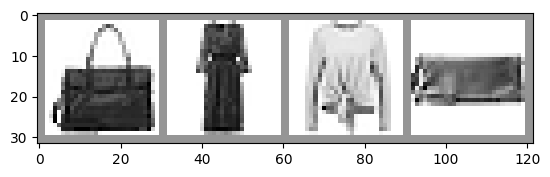

In [111]:
import matplotlib.pyplot as plt
import numpy as np

# Helper function for inline image display
def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

dataiter = iter(training_loader)
images, labels = next(dataiter)

# Create a grid from the images and show them
img_grid = torchvision.utils.make_grid(images)
matplotlib_imshow(img_grid, one_channel=True)
print('  '.join(classes[labels[j]] for j in range(4)))

In [112]:
import torch.nn as nn
import torch.nn.functional as F

# PyTorch models inherit from torch.nn.Module
class GarmentClassifier(nn.Module):
    def __init__(self):
        super(GarmentClassifier, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        self.fc4 = nn.Linear(10, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x


model = GarmentClassifier()

In [113]:
loss_fn = torch.nn.CrossEntropyLoss()

# NB: Loss functions expect data in batches, so we're creating batches of 4
# Represents the model's confidence in each of the 10 classes for a given input
dummy_outputs = torch.rand(4, 10)
# Represents the correct class among the 10 being tested
dummy_labels = torch.tensor([1, 5, 3, 7])

print(dummy_outputs)
print(dummy_labels)

loss = loss_fn(dummy_outputs, dummy_labels)
print('Total loss for this batch: {}'.format(loss.item()))

tensor([[0.2437, 0.1755, 0.8466, 0.9197, 0.4387, 0.0044, 0.7735, 0.6756, 0.8830,
         0.5034],
        [0.9966, 0.3966, 0.8326, 0.3015, 0.8531, 0.1095, 0.1387, 0.5912, 0.3153,
         0.4646],
        [0.3591, 0.8919, 0.6393, 0.1234, 0.6654, 0.7860, 0.9578, 0.4994, 0.8815,
         0.0557],
        [0.9615, 0.0562, 0.7238, 0.9760, 0.1245, 0.3659, 0.0983, 0.3897, 0.7563,
         0.7800]])
tensor([1, 5, 3, 7])
Total loss for this batch: 2.6892051696777344


In [125]:
# Optimizers specified in the torch.optim package
optimizer = torch.optim.SGD(model.parameters(), lr=0.0001, momentum=0.1)

In [126]:
def train_one_epoch(epoch_index, tb_writer):
    running_loss = 0.
    last_loss = 0.

    for i, data in enumerate(training_loader):
        inputs, labels = data

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        
        if i% 1000 == 999:
            last_loss = running_loss / 1000 # loss per batch
            print('  batch {} loss: {}'.format(i + 1, last_loss))
            tb_x = epoch_index * len(training_loader) + i + 1
            tb_writer.add_scalar('Loss/train', last_loss, tb_x)
            running_loss = 0.

    return last_loss


In [127]:
# Initializing in a separate cell so we can easily add more epochs to the same run
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
writer = SummaryWriter('runs/fashion_trainer_{}'.format(timestamp))
epoch_number = 0

EPOCHS = 5

best_vloss = 1_000_000.

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(epoch_number, writer)


    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(validation_loader):
            vinputs, vlabels = vdata
            voutputs = model(vinputs)
            vloss = loss_fn(voutputs, vlabels)
            running_vloss += vloss

    avg_vloss = running_vloss / (i + 1)
    print('LOSS train {} valid {}'.format(avg_loss, avg_vloss))

    # Log the running loss averaged per batch
    # for both training and validation
    writer.add_scalars('Training vs. Validation Loss',
                    { 'Training' : avg_loss, 'Validation' : avg_vloss },
                    epoch_number + 1)
    writer.flush()

    # Track best performance, and save the model's state
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = 'model_{}_{}'.format(timestamp, epoch_number)
        torch.save(model.state_dict(), model_path)

    epoch_number += 1

EPOCH 1:
  batch 1000 loss: 0.4722209343506394
  batch 2000 loss: 0.4541018147744571
  batch 3000 loss: 0.44486744347320745
  batch 4000 loss: 0.40224360874190757
  batch 5000 loss: 0.39379195334064193
  batch 6000 loss: 0.4176499873680841
  batch 7000 loss: 0.39037179092162205
  batch 8000 loss: 0.4151283759422226
  batch 9000 loss: 0.39718542578250254
  batch 10000 loss: 0.3844859144569989
  batch 11000 loss: 0.4257357690522386
  batch 12000 loss: 0.3830781638804751
  batch 13000 loss: 0.3782535171740258
  batch 14000 loss: 0.38646137521193624
  batch 15000 loss: 0.36370274003845815
LOSS train 0.36370274003845815 valid 0.42940908670425415
EPOCH 2:
  batch 1000 loss: 0.3666808984148771
  batch 2000 loss: 0.3927763651295634
  batch 3000 loss: 0.3672386154546455
  batch 4000 loss: 0.3767902562049494
  batch 5000 loss: 0.3566729879545053
  batch 6000 loss: 0.36876794811295893
  batch 7000 loss: 0.36477883350426576
  batch 8000 loss: 0.3720262163926406
  batch 9000 loss: 0.352775589733873

In [123]:
PATH = "/Users/hakonstoren/Python_i_VSCODE/Cogito/Depptactics-arena/deeptactics-arena/notebooks/environments/model_20260303_193139_4"

saved_model = GarmentClassifier()
saved_model.load_state_dict(torch.load(PATH))

<All keys matched successfully>

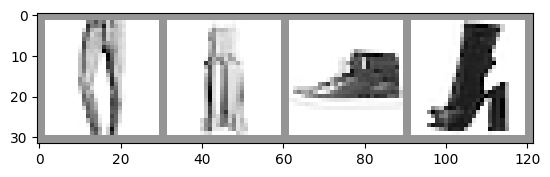

Correct:  ['Trouser', 'Dress', 'Sneaker', 'Ankle Boot']
Predicted:  ['Trouser', 'Dress', 'Sneaker', 'Sandal']
We got 86.37 % correct


In [124]:

correct = 0
total = 0
with torch.no_grad():
    for i, vdata in enumerate(validation_loader):
        vinputs, vlabels = vdata
        voutputs = saved_model(vinputs)

        chosen = torch.argmax(voutputs, axis=1)
        correct += torch.sum(chosen == vlabels)
        total += 4

        if i % 10000 == 999:
            img_grid = torchvision.utils.make_grid(vinputs)
            matplotlib_imshow(img_grid, one_channel=True)
            plt.show()
            print("Correct: ", [classes[l] for l in vlabels])
            print("Predicted: ", [classes[l] for l in torch.argmax(voutputs, axis=1)])
print(f"We got {correct/total*100:.2f} % correct")